In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Imbalance Handling (for Task 2)
from imblearn.over_sampling import SMOTE

# Utility
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
fraud_df = pd.read_csv(
    "../data/processed/fraud_clean.csv"
)

ip_df = pd.read_csv(
    "../data/raw/IpAddress_to_Country.csv"
)

fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [4]:
fraud_df["signup_time"] = pd.to_datetime(
    fraud_df["signup_time"]
)

fraud_df["purchase_time"] = pd.to_datetime(
    fraud_df["purchase_time"]
)

In [5]:
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"]
    - fraud_df["signup_time"]
).dt.total_seconds()

In [6]:
fraud_df["hour_of_day"] = (
    fraud_df["purchase_time"]
    .dt.hour
)

In [7]:
fraud_df["day_of_week"] = (
    fraud_df["purchase_time"]
    .dt.dayofweek
)

In [8]:
user_txn_count = (
    fraud_df.groupby("user_id")
    .size()
)

fraud_df["user_transaction_count"] = (
    fraud_df["user_id"]
    .map(user_txn_count)
)

In [9]:
device_txn_count = (
    fraud_df.groupby("device_id")
    .size()
)

fraud_df["device_transaction_count"] = (
    fraud_df["device_id"]
    .map(device_txn_count)
)

In [10]:
fraud_df["ip_address"] = (
    fraud_df["ip_address"]
    .astype(np.int64)
)

ip_df["lower_bound_ip_address"] = (
    ip_df["lower_bound_ip_address"]
    .astype(np.int64)
)

ip_df["upper_bound_ip_address"] = (
    ip_df["upper_bound_ip_address"]
    .astype(np.int64)
)

In [11]:
ip_df = ip_df.sort_values(
    "lower_bound_ip_address"
)

In [12]:
fraud_df = fraud_df.sort_values(
    "ip_address"
)

fraud_geo = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

In [13]:
fraud_geo = fraud_geo[
    fraud_geo["ip_address"]
    <= fraud_geo["upper_bound_ip_address"]
]

In [14]:
country_fraud = (
    fraud_geo.groupby("country")["class"]
    .mean()
    .sort_values(ascending=False)
)

country_fraud.head(20)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Malta                    0.181818
Afghanistan              0.166667
Cote D'ivoire            0.166667
Denmark                  0.159184
Chile                    0.153477
Name: class, dtype: float64

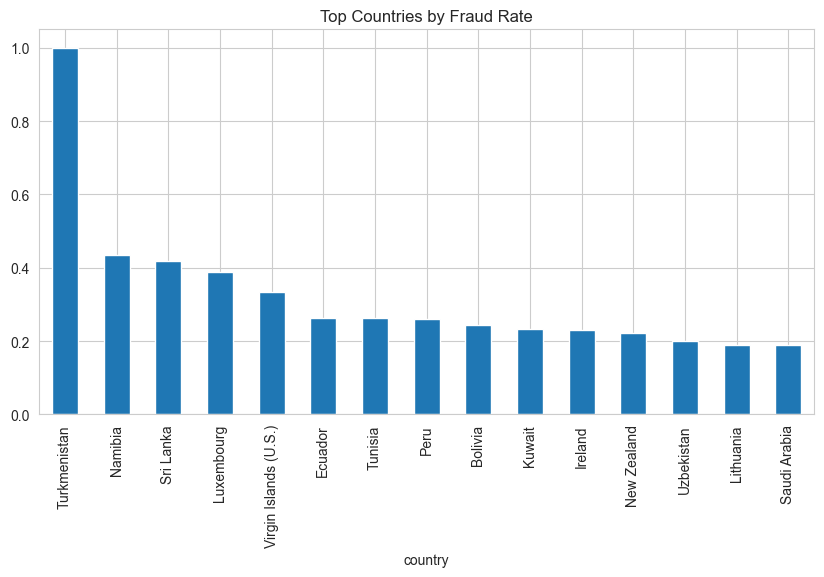

In [15]:
country_fraud.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top Countries by Fraud Rate"
)

plt.show()

In [16]:
fraud_geo = pd.get_dummies(
    fraud_geo,
    columns=[
        "source",
        "browser",
        "sex",
        "country"
    ],
    drop_first=True
)

In [17]:
fraud_geo.to_csv(
    "../data/processed/fraud_featured.csv",
    index=False
)